In [1]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
ds_run = xr.open_dataset("GFS_2022111700.nc")
ds_run

sh: 1: getfattr: not found


<xarray.Dataset> Size: 8MB
Dimensions:            (valid_time: 15, latitude: 41, longitude: 81,
                        isobaricInhPa: 5)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * latitude           (latitude) float64 328B 50.0 49.75 49.5 ... 40.25 40.0
  * longitude          (longitude) float64 648B 275.0 275.2 ... 294.8 295.0
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables: (12/14)
    orog               (valid_time, latitude, longitude) float32 199kB ...
    tS                 (valid_time, latitude, longitude) float32 199kB ...
    sit                (valid_time, latitude, longitude) float32 199kB ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    ...                 ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t2m                (valid_time, latitude, longitude) float32 199kB ...
    r2                 (valid_time, latitude, longitude) float32 199kB ...
    aptmp              (valid_time, latitude, longitude) float32 199kB ...
    tp                 (valid_time, latitude, longitude) float32 199kB ...
    prmsl              (valid_time, latitude, longitude) float32 199kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-01T16:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
def basemap():
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-85,-65, 40, 50])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    return fig, ax

## Data

In [4]:
run_current = pd.Timestamp("now", tz="utc").replace(tzinfo=None).floor('24h')
pd.Timestamp("2026-03-14-00")

Timestamp('2026-03-14 00:00:00')

In [3]:
run = pd.Timestamp("2022-11-18-00", tz="utc").replace(tzinfo=None).floor('24h')
run

Timestamp('2022-11-18 00:00:00')

In [4]:
H_current = Herbie(run_current, model="ifs", product="oper", fxx=6, save_dir='./data/', overwrite=True)

NameError: name 'run_current' is not defined

In [56]:
H = Herbie(run, model="gfs", product="pgrb2.0p25", fxx=6, save_dir='./data/', overwrite=True)

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2022-Nov-18 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws


In [57]:
df = H.inventory()
df

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,994548.0,0-994548,2022-11-18,2022-11-18 06:00:00,PRMSL,mean sea level,6 hour fcst,:PRMSL:mean sea level:6 hour fcst
1,2,994549,1068924.0,994549-1068924,2022-11-18,2022-11-18 06:00:00,CLWMR,1 hybrid level,6 hour fcst,:CLWMR:1 hybrid level:6 hour fcst
2,3,1068925,1386079.0,1068925-1386079,2022-11-18,2022-11-18 06:00:00,ICMR,1 hybrid level,6 hour fcst,:ICMR:1 hybrid level:6 hour fcst
3,4,1386080,1642501.0,1386080-1642501,2022-11-18,2022-11-18 06:00:00,RWMR,1 hybrid level,6 hour fcst,:RWMR:1 hybrid level:6 hour fcst
4,5,1642502,1754904.0,1642502-1754904,2022-11-18,2022-11-18 06:00:00,SNMR,1 hybrid level,6 hour fcst,:SNMR:1 hybrid level:6 hour fcst
...,...,...,...,...,...,...,...,...,...,...
738,739,543773085,544415168.0,543773085-544415168,2022-11-18,2022-11-18 06:00:00,VGRD,PV=-2e-06 (Km^2/kg/s) surface,6 hour fcst,:VGRD:PV=-2e-06 (Km^2/kg/s) surface:6 hour fcst
739,740,544415169,545052384.0,544415169-545052384,2022-11-18,2022-11-18 06:00:00,TMP,PV=-2e-06 (Km^2/kg/s) surface,6 hour fcst,:TMP:PV=-2e-06 (Km^2/kg/s) surface:6 hour fcst
740,741,545052385,546193938.0,545052385-546193938,2022-11-18,2022-11-18 06:00:00,HGT,PV=-2e-06 (Km^2/kg/s) surface,6 hour fcst,:HGT:PV=-2e-06 (Km^2/kg/s) surface:6 hour fcst
741,742,546193939,547297700.0,546193939-547297700,2022-11-18,2022-11-18 06:00:00,PRES,PV=-2e-06 (Km^2/kg/s) surface,6 hour fcst,:PRES:PV=-2e-06 (Km^2/kg/s) surface:6 hour fcst


In [58]:
ss = r"((HGT|TMP|UGRD|VGRD|RH|TCDC):(2 m above ground|1000|850|700|500|250)|:PRMSL:mean sea level:6 hour fcst|APCP)"
H.inventory(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,994548.0,0-994548,2022-11-18,2022-11-18 06:00:00,PRMSL,mean sea level,6 hour fcst,:PRMSL:mean sea level:6 hour fcst
268,269,210752511,211494455.0,210752511-211494455,2022-11-18,2022-11-18 06:00:00,HGT,250 mb,6 hour fcst,:HGT:250 mb:6 hour fcst
269,270,211494456,212249770.0,211494456-212249770,2022-11-18,2022-11-18 06:00:00,TMP,250 mb,6 hour fcst,:TMP:250 mb:6 hour fcst
270,271,212249771,213072759.0,212249771-213072759,2022-11-18,2022-11-18 06:00:00,RH,250 mb,6 hour fcst,:RH:250 mb:6 hour fcst
271,272,213072760,213532023.0,213072760-213532023,2022-11-18,2022-11-18 06:00:00,TCDC,250 mb,6 hour fcst,:TCDC:250 mb:6 hour fcst
275,276,216880492,217477388.0,216880492-217477388,2022-11-18,2022-11-18 06:00:00,UGRD,250 mb,6 hour fcst,:UGRD:250 mb:6 hour fcst
276,277,217477389,218076996.0,217477389-218076996,2022-11-18,2022-11-18 06:00:00,VGRD,250 mb,6 hour fcst,:VGRD:250 mb:6 hour fcst
348,349,264446436,265263615.0,264446436-265263615,2022-11-18,2022-11-18 06:00:00,HGT,500 mb,6 hour fcst,:HGT:500 mb:6 hour fcst
349,350,265263616,265993675.0,265263616-265993675,2022-11-18,2022-11-18 06:00:00,TMP,500 mb,6 hour fcst,:TMP:500 mb:6 hour fcst
350,351,265993676,266815168.0,265993676-266815168,2022-11-18,2022-11-18 06:00:00,RH,500 mb,6 hour fcst,:RH:500 mb:6 hour fcst


In [76]:
ss_sfc = r"((HGT|TMP|UGRD|VGRD|RH|TCDC|LSM):(surface))"
H.inventory(ss_sfc)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
62,63,30820740,32974434.0,30820740-32974434,2026-04-08,2026-04-08,HGT,surface,anl,:HGT:surface:anl
63,64,32974435,34301975.0,32974435-34301975,2026-04-08,2026-04-08,TMP,surface,anl,:TMP:surface:anl


In [77]:
fp_surface = H.download(ss_sfc)
fp_surface

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


PosixPath('/home/jhk5405/data/hrrr/20260408/subset_7befbcc2__hrrr.t00z.wrfsfcf00.grib2')

In [78]:
fp = H.download(ss)
fp

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


PosixPath('/home/jhk5405/data/hrrr/20260408/subset_7befef6f__hrrr.t00z.wrfsfcf00.grib2')

In [79]:
fp_sfc = H.download(ss_sfc)
fp_sfc

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


PosixPath('/home/jhk5405/data/hrrr/20260408/subset_7befbcc2__hrrr.t00z.wrfsfcf00.grib2')

In [80]:
ds = xr.open_dataset(fp,engine = "cfgrib")
ds

skipping variable: paramId==156 shortName='gh'
Traceback (most recent call last):
  File "/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  850.,  700.,  500.,  250.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  850.,  700.,  500.]))
skipping variable: paramId==130 shortName='t'
Traceback (most recent call last):
  File "/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/dataset.py", line 726, in build_dataset_component

<xarray.Dataset> Size: 130MB
Dimensions:            (isobaricInhPa: 5, y: 1059, x: 1799)
Coordinates:
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    valid_time         datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u                  (isobaricInhPa, y, x) float32 38MB ...
    v                  (isobaricInhPa, y, x) float32 38MB ...
    t2m                (y, x) float32 8MB ...
    r2                 (y, x) float32 8MB ...
    tp                 (y, x) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T13:50 GRIB to CDM+CF via cfgrib-0.9.1...

In [64]:
ds_sfc = xr.open_dataset(fp_sfc,engine = "cfgrib")
ds_sfc

Ignoring index file 'data/gfs/20221118/subset_37b2f53b__gfs.t00z.pgrb2.0p25.f006.5b7b6.idx' older than GRIB file


<xarray.Dataset> Size: 12MB
Dimensions:     (latitude: 721, longitude: 1440)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    orog        (latitude, longitude) float32 4MB ...
    t           (latitude, longitude) float32 4MB ...
    sit         (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T13:46 GRIB to CDM+CF via cfgrib-0.9.1...

## Maps

In [243]:
def basemap():
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-85,-65, 40, 50])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    return fig, ax

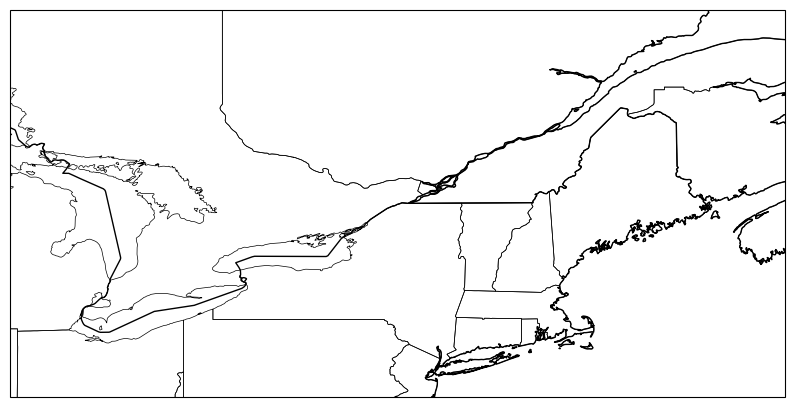

In [244]:
fig, ax = basemap()

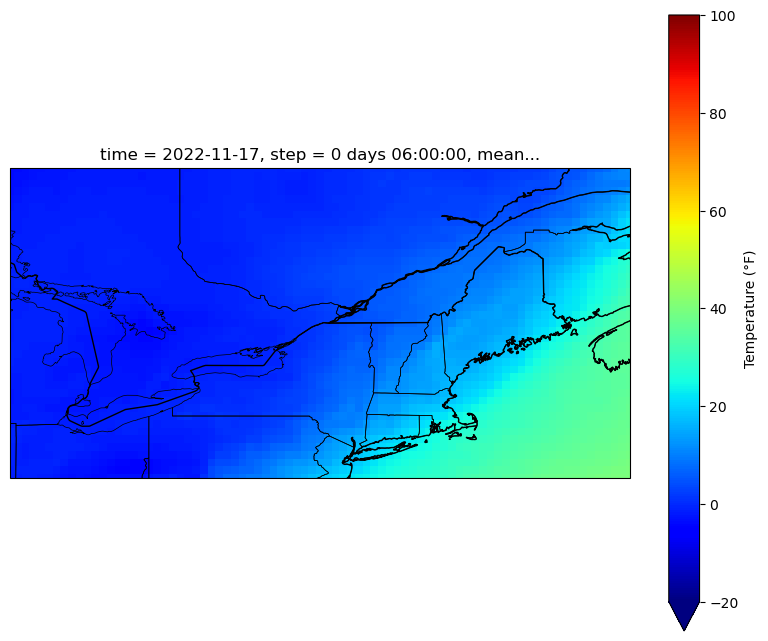

In [245]:
fig, ax = basemap()

temp_f700 = (ds['t'].sel(isobaricInhPa=700) - 273.15) * 9/5 + 32

temp_f700.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet',
    vmin=-20, vmax=100,
    cbar_kwargs={'label': 'Temperature (°F)'}
)

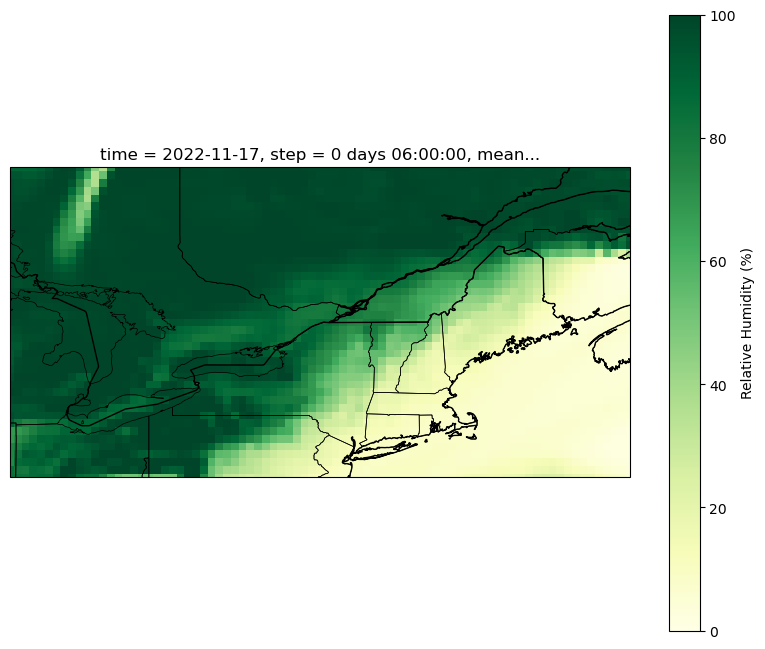

In [246]:
fig, ax = basemap()

RH = ds['r'].sel(isobaricInhPa=700)

RH.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    cbar_kwargs={'label': 'Relative Humidity (%)'}
)

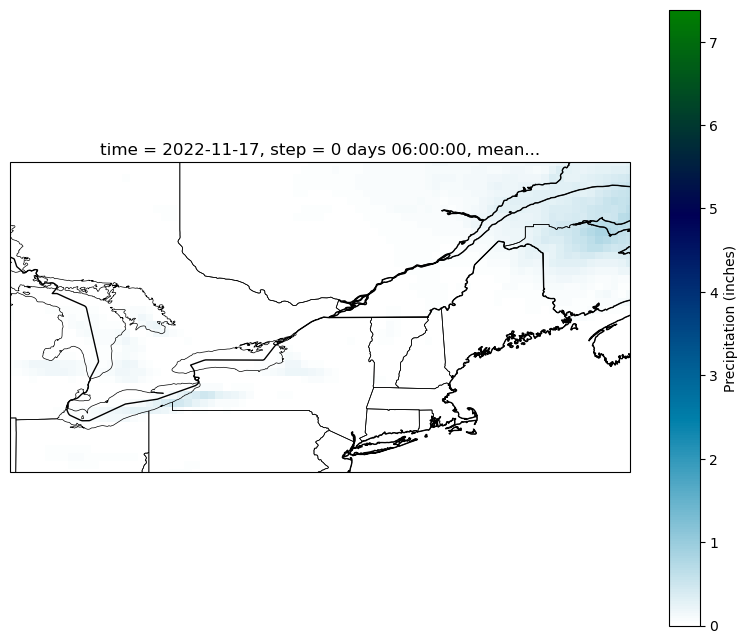

In [247]:
fig, ax = basemap()

apcp = ds['tp'] * 0.0393701   # mm → inches

apcp.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='ocean_r',
    cbar_kwargs={'label': 'Precipitation (inches)'}
)

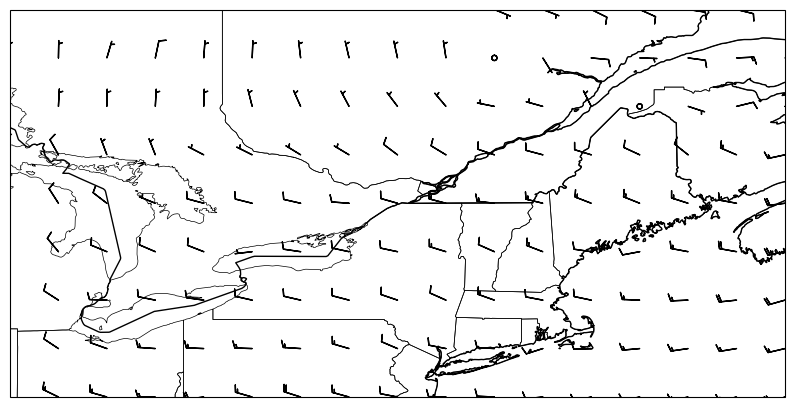

In [248]:
fig, ax = basemap()

u = ds['u'].sel(isobaricInhPa=850)
v = ds['v'].sel(isobaricInhPa=850)

skip = 5  # increase this number to reduce density

ax.barbs(
    ds.longitude.values[::skip],
    ds.latitude.values[::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
    length=5
)

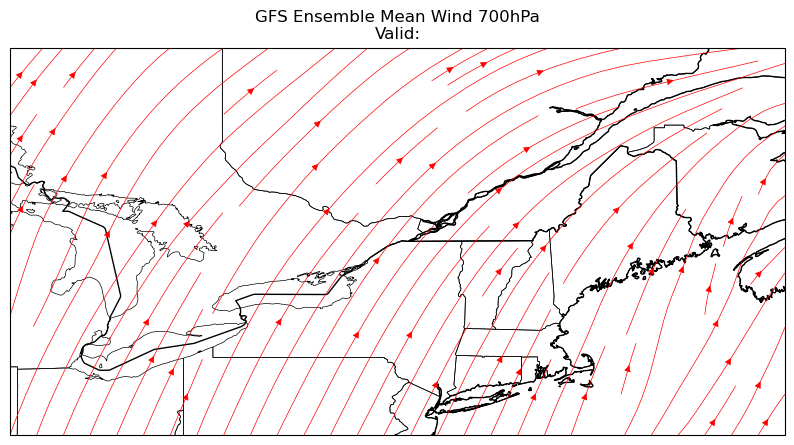

In [249]:
gh500 = ds['gh'].sel(isobaricInhPa=850)
u500 = ds['u'].sel(isobaricInhPa=850)
v500 = ds['v'].sel(isobaricInhPa=850)

ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
ds = ds.sortby('longitude')
ds = ds.sortby('latitude')

fig, ax = basemap()

ax.streamplot(ds.longitude.values, ds.latitude.values, u500.values, v500.values, transform=ccrs.PlateCarree(), density=1, linewidth = 0.5, color="red")
ax.set_title(f"GFS Ensemble Mean Wind 700hPa\n" f"Valid:")

plt.show()

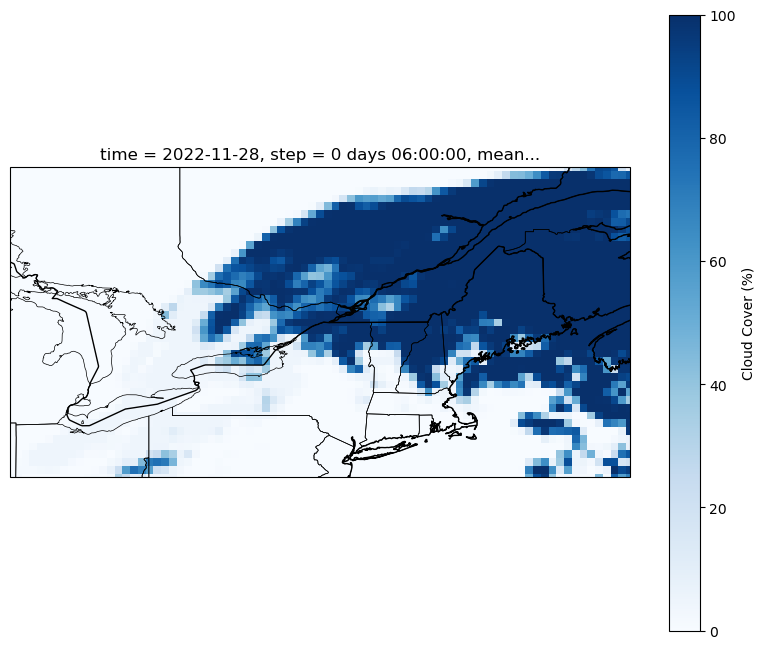

In [318]:
fig, ax = basemap()

tcc = ds['tcc'].sel(isobaricInhPa=700)

tcc.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Cloud Cover (%)'}
)

NameError: name 'ds_sfc' is not defined

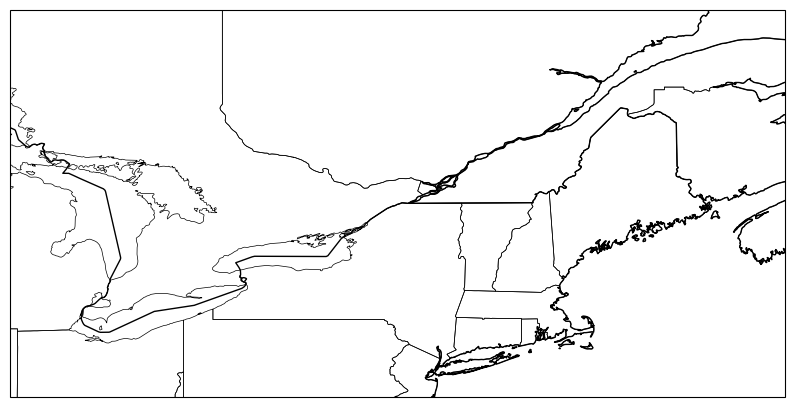

In [32]:
fig, ax = basemap()

temp_f1000 = ((ds_sfc['t'] - 273.15) * 9/5) + 32

temp_f1000.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet',
    vmin=-10, vmax=100,
    cbar_kwargs={'label': 'Temperature (°F)'}
)

## Model

In [13]:
H_m = FastHerbie([run], model="gfs", product="pgrb2.0p25", fxx=np.arange(0,90,6).tolist(), save_dir='./data/', overwrite=True)

In [14]:
filepath = H_m.download(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [15]:
filepath

[PosixPath('data/gfs/20221117/subset_4cef3811__gfs.t00z.pgrb2.0p25.f000'),
 PosixPath('data/gfs/20221117/subset_4c0ec797__gfs.t00z.pgrb2.0p25.f024'),
 PosixPath('data/gfs/20221117/subset_4c05c797__gfs.t00z.pgrb2.0p25.f084'),
 PosixPath('data/gfs/20221117/subset_4cb2d022__gfs.t00z.pgrb2.0p25.f006'),
 PosixPath('data/gfs/20221117/subset_4c32c797__gfs.t00z.pgrb2.0p25.f066'),
 PosixPath('data/gfs/20221117/subset_4c60c797__gfs.t00z.pgrb2.0p25.f030'),
 PosixPath('data/gfs/20221117/subset_4c43c797__gfs.t00z.pgrb2.0p25.f060'),
 PosixPath('data/gfs/20221117/subset_4c12c797__gfs.t00z.pgrb2.0p25.f012'),
 PosixPath('data/gfs/20221117/subset_4ce7c797__gfs.t00z.pgrb2.0p25.f042'),
 PosixPath('data/gfs/20221117/subset_4c5ec797__gfs.t00z.pgrb2.0p25.f078'),
 PosixPath('data/gfs/20221117/subset_4cf1c797__gfs.t00z.pgrb2.0p25.f072'),
 PosixPath('data/gfs/20221117/subset_4c1cc797__gfs.t00z.pgrb2.0p25.f048'),
 PosixPath('data/gfs/20221117/subset_4c0ec797__gfs.t00z.pgrb2.0p25.f036'),
 PosixPath('data/gfs/2022

In [16]:
filepath_sfc = H_m.download(ss_sfc)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [17]:
filepath_sfc

[PosixPath('data/gfs/20221117/subset_4cb2f53b__gfs.t00z.pgrb2.0p25.f006'),
 PosixPath('data/gfs/20221117/subset_4cef1479__gfs.t00z.pgrb2.0p25.f000'),
 PosixPath('data/gfs/20221117/subset_4ce7f53b__gfs.t00z.pgrb2.0p25.f042'),
 PosixPath('data/gfs/20221117/subset_4c12f53b__gfs.t00z.pgrb2.0p25.f012'),
 PosixPath('data/gfs/20221117/subset_4c60f53b__gfs.t00z.pgrb2.0p25.f030'),
 PosixPath('data/gfs/20221117/subset_4c32f53b__gfs.t00z.pgrb2.0p25.f066'),
 PosixPath('data/gfs/20221117/subset_4c0ef53b__gfs.t00z.pgrb2.0p25.f036'),
 PosixPath('data/gfs/20221117/subset_4cf1f53b__gfs.t00z.pgrb2.0p25.f072'),
 PosixPath('data/gfs/20221117/subset_4c78f53b__gfs.t00z.pgrb2.0p25.f054'),
 PosixPath('data/gfs/20221117/subset_4c05f53b__gfs.t00z.pgrb2.0p25.f084'),
 PosixPath('data/gfs/20221117/subset_4c43f53b__gfs.t00z.pgrb2.0p25.f060'),
 PosixPath('data/gfs/20221117/subset_4c5ef53b__gfs.t00z.pgrb2.0p25.f078'),
 PosixPath('data/gfs/20221117/subset_4c0ef53b__gfs.t00z.pgrb2.0p25.f024'),
 PosixPath('data/gfs/2022

In [18]:
ds_r_var = xr.open_mfdataset(filepath, combine='nested', concat_dim='valid_time', engine='cfgrib', coords='minimal', compat='override')
ds_r_var

Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4cef3811__gfs.t00z.pgrb2.0p25.f000.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c0ec797__gfs.t00z.pgrb2.0p25.f024.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c05c797__gfs.t00z.pgrb2.0p25.f084.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4cb2d022__gfs.t00z.pgrb2.0p25.f006.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c32c797__gfs.t00z.pgrb2.0p25.f066.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c60c797__gfs.t00z.pgrb2.0p25.f030.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c4

<xarray.Dataset> Size: 2GB
Dimensions:            (valid_time: 15, isobaricInhPa: 5, latitude: 721,
                        longitude: 1440)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
    meanSea            float64 8B ...
Data variables:
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    tcc                (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    t2m                (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    r2                 (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    aptmp              (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    prmsl              (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [19]:
ds_r_sfc = xr.open_mfdataset(filepath_sfc, combine='nested', concat_dim='valid_time', engine='cfgrib', coords='minimal', compat='override')
ds_r_sfc

Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4cb2f53b__gfs.t00z.pgrb2.0p25.f006.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4cef1479__gfs.t00z.pgrb2.0p25.f000.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4ce7f53b__gfs.t00z.pgrb2.0p25.f042.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c12f53b__gfs.t00z.pgrb2.0p25.f012.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c60f53b__gfs.t00z.pgrb2.0p25.f030.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c32f53b__gfs.t00z.pgrb2.0p25.f066.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group5/data/gfs/20221117/subset_4c0

<xarray.Dataset> Size: 187MB
Dimensions:     (valid_time: 15, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 120B 2022-11-17T06:00:00 ... 2022...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    orog        (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    t           (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sit         (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [20]:
ds_r_sfc = ds_r_sfc.rename({"t": "tS"})
ds_r_sfc

<xarray.Dataset> Size: 187MB
Dimensions:     (valid_time: 15, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 120B 2022-11-17T06:00:00 ... 2022...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    orog        (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tS          (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sit         (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [21]:
ds_r = xr.merge([ds_r_sfc,ds_r_var],compat='override')

/tmp/ipykernel_1998292/2170563126.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds_r = xr.merge([ds_r_sfc,ds_r_var],compat='override')


In [22]:
ds_r = ds_r.sortby('valid_time')
ds_r

<xarray.Dataset> Size: 2GB
Dimensions:            (latitude: 721, longitude: 1440, valid_time: 15,
                        isobaricInhPa: 5)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables: (12/14)
    orog               (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tS                 (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sit                (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    ...                 ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 311MB dask.array<chunksize=(1, 5, 721, 1440), meta=np.ndarray>
    t2m                (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    r2                 (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    aptmp              (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    prmsl              (valid_time, latitude, longitude) float32 62MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [23]:
ds_r = ds_r.sel(latitude=slice(50, 40), longitude=slice(275,295))
ds_r

<xarray.Dataset> Size: 8MB
Dimensions:            (latitude: 41, longitude: 81, valid_time: 15,
                        isobaricInhPa: 5)
Coordinates:
  * latitude           (latitude) float64 328B 50.0 49.75 49.5 ... 40.25 40.0
  * longitude          (longitude) float64 648B 275.0 275.2 ... 294.8 295.0
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables: (12/14)
    orog               (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    tS                 (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    sit                (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 996kB dask.array<chunksize=(1, 5, 41, 81), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB dask.array<chunksize=(1, 5, 41, 81), meta=np.ndarray>
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB dask.array<chunksize=(1, 5, 41, 81), meta=np.ndarray>
    ...                 ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB dask.array<chunksize=(1, 5, 41, 81), meta=np.ndarray>
    t2m                (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    r2                 (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    aptmp              (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
    prmsl              (valid_time, latitude, longitude) float32 199kB dask.array<chunksize=(1, 41, 81), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [24]:
fname = f'GFS_{run:%Y%m%d%H}.nc'
ds_r.to_netcdf(fname)

In [25]:
ds_run = xr.open_dataset(fname)
ds_run

sh: 1: getfattr: not found


<xarray.Dataset> Size: 8MB
Dimensions:            (valid_time: 15, latitude: 41, longitude: 81,
                        isobaricInhPa: 5)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * latitude           (latitude) float64 328B 50.0 49.75 49.5 ... 40.25 40.0
  * longitude          (longitude) float64 648B 275.0 275.2 ... 294.8 295.0
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables: (12/14)
    orog               (valid_time, latitude, longitude) float32 199kB ...
    tS                 (valid_time, latitude, longitude) float32 199kB ...
    sit                (valid_time, latitude, longitude) float32 199kB ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    ...                 ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t2m                (valid_time, latitude, longitude) float32 199kB ...
    r2                 (valid_time, latitude, longitude) float32 199kB ...
    aptmp              (valid_time, latitude, longitude) float32 199kB ...
    tp                 (valid_time, latitude, longitude) float32 199kB ...
    prmsl              (valid_time, latitude, longitude) float32 199kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

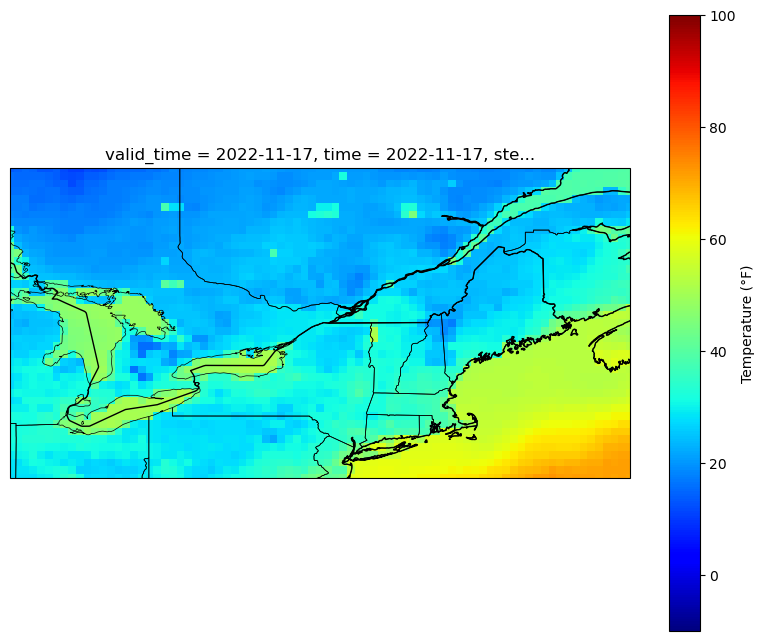

In [50]:
fig, ax = basemap()

temp_f1000 = ((ds_r['t'].isel(valid_time=0) - 273.15) * 9/5) + 32

temp_f1000.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet',
    vmin=-10, vmax=100,
    cbar_kwargs={'label': 'Temperature (°F)'}
)

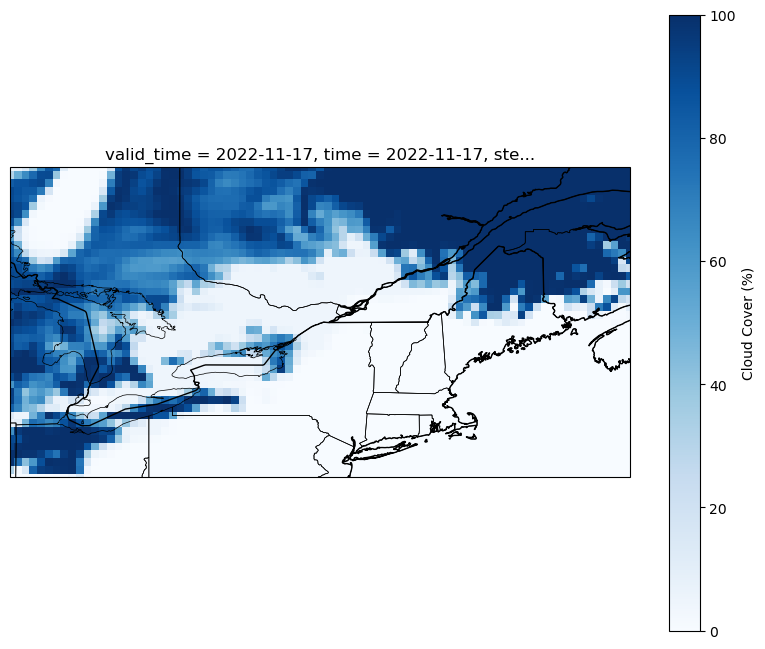

In [51]:
fig, ax = basemap()

tcc = ds_r['tcc'].sel(isobaricInhPa=700).isel(valid_time=0)

tcc.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Cloud Cover (%)'}
)

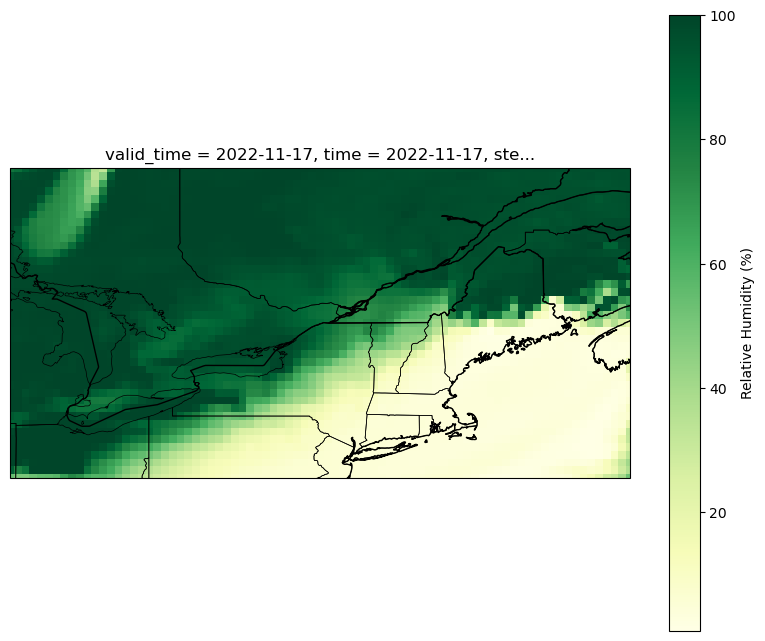

In [6]:
fig, ax = basemap()

RH = ds_r['r'].sel(isobaricInhPa=7).isel(valid_time=0)

RH.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    cbar_kwargs={'label': 'Relative Humidity (%)'}
)

## Calculated Data

In [ ]:
ds_run = xr.open_dataset("GFS_2022111700.nc")
ds_run

In [38]:
delta_T = ds_run["tS"] - ds_run["t"].sel(isobaricInhPa=850)

<xarray.DataArray (valid_time: 15, latitude: 41, longitude: 81)> Size: 199kB
array([[[ 3.5862122,  4.4162292,  4.8862   , ..., 15.036224 ,
         15.12619  , 15.1762085],
        [ 4.7762146,  4.656189 ,  5.0062256, ..., 14.37619  ,
         14.576202 , 14.956207 ],
        [ 4.816223 ,  5.096222 ,  5.1662292, ..., 14.006195 ,
         14.376221 , 14.516235 ],
        ...,
        [ 7.62619  ,  7.2862244,  8.126221 , ..., 10.106201 ,
         10.216217 , 10.476227 ],
        [ 7.7062073,  7.726227 ,  7.576233 , ...,  9.496216 ,
          9.836243 ,  9.946228 ],
        [ 7.9262085,  7.9362183,  7.7562256, ...,  9.276215 ,
          9.536224 ,  9.466217 ]],

       [[ 3.0931702,  4.3931885,  5.2731934, ..., 13.773193 ,
         13.723206 , 13.733154 ],
        [ 4.09317  ,  4.4031982,  5.0631714, ..., 14.073181 ,
         13.9131775, 13.59317  ],
        [ 4.0631714,  4.4732056,  4.9031677, ..., 13.243164 ,
         13.133179 , 12.813171 ],
...
        [ 7.601776 ,  8.041779 ,  8.151794 , ..., 20.901764 ,
         20.971802 , 20.721802 ],
        [ 6.3617554,  7.201782 ,  7.6617737, ..., 20.721771 ,
         20.661804 , 20.141785 ],
        [ 6.00177  ,  6.831787 ,  7.4017944, ..., 19.851776 ,
         19.731781 , 19.49179  ]],

       [[ 0.8254242,  1.905426 ,  2.5854187, ..., 15.045441 ,
         15.265411 , 15.465424 ],
        [ 2.5254211,  2.605423 ,  2.7354279, ..., 14.54541  ,
         14.735413 , 15.045441 ],
        [ 2.7454224,  3.30542  ,  3.3254242, ..., 14.465424 ,
         14.755432 , 14.935425 ],
        ...,
        [ 4.5854187,  5.5454407,  5.9954224, ..., 19.445435 ,
         19.845398 , 19.415405 ],
        [ 2.6854248,  3.9554138,  4.8654175, ..., 19.28543  ,
         19.255402 , 18.725403 ],
        [ 1.7554321,  3.385437 ,  4.2054443, ..., 18.57544  ,
         18.695404 , 18.55545  ]]], shape=(15, 41, 81), dtype=float32)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * latitude           (latitude) float64 328B 50.0 49.75 49.5 ... 40.25 40.0
  * longitude          (longitude) float64 648B 275.0 275.2 ... 294.8 295.0
    time               datetime64[ns] 8B 2022-11-17
    step               timedelta64[ns] 8B 06:00:00
    surface            float64 8B 0.0
    heightAboveGround  float64 8B 2.0
    meanSea            float64 8B 0.0
    isobaricInhPa      float64 8B 850.0
Attributes: (12/29)
    GRIB_paramId:                             130
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_name:                                Temperature
    GRIB_shortName:                           t
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_temperature

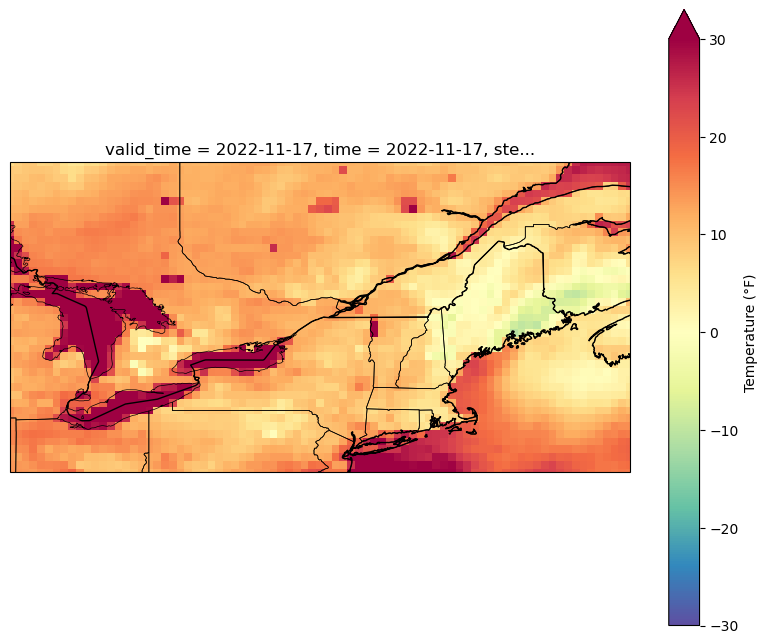

In [52]:
fig, ax = basemap()

delta_T = ((((ds_run["tS"] - 273.15) * 9/5) + 32) - (((ds_run["t"].sel(isobaricInhPa=850) - 273.15) * 9/5) + 32)).isel(valid_time=0)

delta_T.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Spectral_r',
    vmin=-30, vmax=30,
    cbar_kwargs={'label': 'Temperature (°F)'}
)

In [322]:
temp_f = (((ds_run["t"].sel(isobaricInhPa=850).values - 273.15) * 9/5) + 32)

In [323]:
# Start with all contributions set to 0
temp_contribution = np.zeros_like(temp_f)

# 38 > T : contibution = 0
mask = temp_f > 38
temp_contribution[mask] = 0

# 32 < T : contribution = 1
mask = temp_f < 32
temp_contribution[mask] = 1.0

# 32 < T < 38 : square root decrease from 1 to 0
mask = (temp_f >= 32) & (temp_f <= 38)
temp_contribution[mask] = np.sqrt(1 - (temp_f[mask] - 32) / 6)

temp_contribution

array([[[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 0.        ,
         0.        , 0.        ],
        [1.        , 1.        , 1.        , ..., 0.        ,
         0.        , 0.        ],
        [1.        , 1.        , 1.        , ..., 0.        ,
         0.        , 0.        ]],

       [[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 0.23380196,
         0.        , 0.        ],
        [1. 

In [324]:
delta_T = ((((ds_run["tS"] - 273.15) * 9/5) + 32) - (((ds_run["t"].sel(isobaricInhPa=850) - 273.15) * 9/5) + 32))

In [325]:
# Start with all contributions set to 0
delta_T_contribution = np.zeros_like(delta_T)

# delta T < 17 : contibution = 0
mask = delta_T < 17
delta_T_contribution[mask] = 0

# delta T >= 23 : contribution = 1
mask = delta_T > 23
delta_T_contribution[mask] = 1.0

# 17 <= delta T < 23: quadratic increase from 0 to 1
mask = (delta_T >=17) & (delta_T <= 23)
delta_T_contribution = (delta_T[mask] - 17) ** 2

delta_T_contribution

IndexError: 3-dimensional boolean indexing is not supported. 

In [326]:
RH = ds_run['r'].sel(isobaricInhPa=7).isel(valid_time=0)

KeyError: "not all values found in index 'isobaricInhPa'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
# Start with all contributions set to 0
RH_contribution = np.zeros_like(RH)

# RH < 70% : contibution = 0
mask = RH < 70
RH_contribution[mask] = 0

# RH >= 80% : contribution = 1
mask = RH > 80
RH_contribution[mask] = 1.0

# 70% <= RH < 80% : square increase from 0 to 1
mask = (RH >= 70) & (RH <= 80)
RH_contribution[mask] = 1.0 - (temp_f[mask] - 90) * (0.5 / 20)

In [ ]:
cc = ds_run['tcc'].sel(isobaricInhPa=700).isel(valid_time=0)

In [327]:
# Start with all contributions set to 0
cc_contribution = np.zeros_like(cc)

# cc < 70% : contibution = 0
mask = cc < 70
cc_contribution[mask] = temp_f[mask] = 0

# cc >= 80% : contribution = 1
mask = cc > 80
cc_contribution[mask] = 1.0

# 70% <= T < 80% : square root increase from 0 to 1
mask = (cc >= 70) & (cc <= 80)
cc_contribution[mask] = 1.0 - (temp_f[mask] - 90) * (0.5 / 20)


NameError: name 'cc' is not defined

In [65]:
step = ds_run['step']
step

AttributeError: 'DataArray' object has no attribute 'int'

## Index Setup / Variables

In [69]:
# Updated search string example
# Note the addition of :LAND:surface or :LSM:surface
search_string = r":TMP:850|:UGRD:850|:VGRD:850|:LAND:surface|:TMP:surface"
H = Herbie("2026-04-08", model="hrrr")
ds_run = H.xarray(search_string)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Apr-08 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly

Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.


In [3]:
import numpy as np
import pandas as pd

def les_index(tS, t850, rh, tcc, tp, u850, v850):
    def get_val(obj):
        if hasattr(obj, 'values'):
            return obj.values.squeeze()
        return np.squeeze(obj)

    # 1. Get raw values
    tS_v = get_val(tS)
    t850_v = get_val(t850)
    rh_v = get_val(rh)
    tcc_v = get_val(tcc)
    tp_v = get_val(tp)
    u_v = get_val(u850)
    v_v = get_val(v850)

    # 2. Pixel-Level Safety Mask (Thermodynamic variables only)
    # If 2 or more of these core variables are NaN at a pixel, it becomes 0%
    core_vars = [tS_v, t850_v, rh_v, tcc_v, tp_v]
    nan_count = np.sum([np.isnan(v) for v in core_vars], axis=0)
    missing_data_mask = (nan_count >= 2)

    # 3. Clean data for math
    tS = np.nan_to_num(tS_v)
    t850 = np.nan_to_num(t850_v)
    rh = np.nan_to_num(rh_v)
    tcc = np.nan_to_num(tcc_v)
    tp = np.nan_to_num(tp_v, nan=0)
    u850 = np.nan_to_num(u_v, nan=0)
    v850 = np.nan_to_num(v_v, nan=0)

    # 4. Thermodynamic Logic
    tS_f = (tS - 273.15) * 9/5 + 32
    t850_f = (t850 - 273.15) * 9/5 + 32
    delta_T = tS_f - t850_f

    # Wind Logic (Still filters for Buffalo/Watertown bands)
    wind_dir = (270 - np.degrees(np.arctan2(v850, u850))) % 360
    f_fetch = np.where((wind_dir >= 220) & (wind_dir <= 290), 1, 0)

    # Ingredient Scaling
    f_dT = np.clip(((delta_T - 15) / 2), 0, 1)
    f_RH = np.clip(((rh - 75) / 20), 0, 1)
    f_P = np.clip((tp / 3.0), 0, 1)
    
    f_T = np.zeros_like(tS_f)
    f_T = np.where((tS_f >= 10) & (tS_f <= 30), 1, f_T)
    f_T = np.where((tS_f > 30), 0, f_T)
    f_T = np.where((tS_f < 10) & (tS_f > -4), ((tS_f + 4) / 14), f_T)

    # 5. Calculate Final Index
    base_index = 100 * (0.1*f_dT + 0.4*f_RH + 0.1*f_T + 0.4*f_P)
    index = base_index 
    
    # Apply pixel mask
    index[missing_data_mask] = 0

    return index

In [8]:
val = 14
les_raw = les_index(
    ds_run['tS'].isel(valid_time=val),
    ds_run['t'].sel(isobaricInhPa=850).isel(valid_time=val),
    ds_run['r'].sel(isobaricInhPa=850).isel(valid_time=val),
    ds_run['tcc'].sel(isobaricInhPa=850).isel(valid_time=val),
    ds_run['tp'].isel(valid_time=val),
    ds_run['u'].sel(isobaricInhPa=850).isel(valid_time=val),
    ds_run['v'].sel(isobaricInhPa=850).isel(valid_time=val)
)

les_t = ds_run['tS'].isel(valid_time=val).copy(data=les_raw)


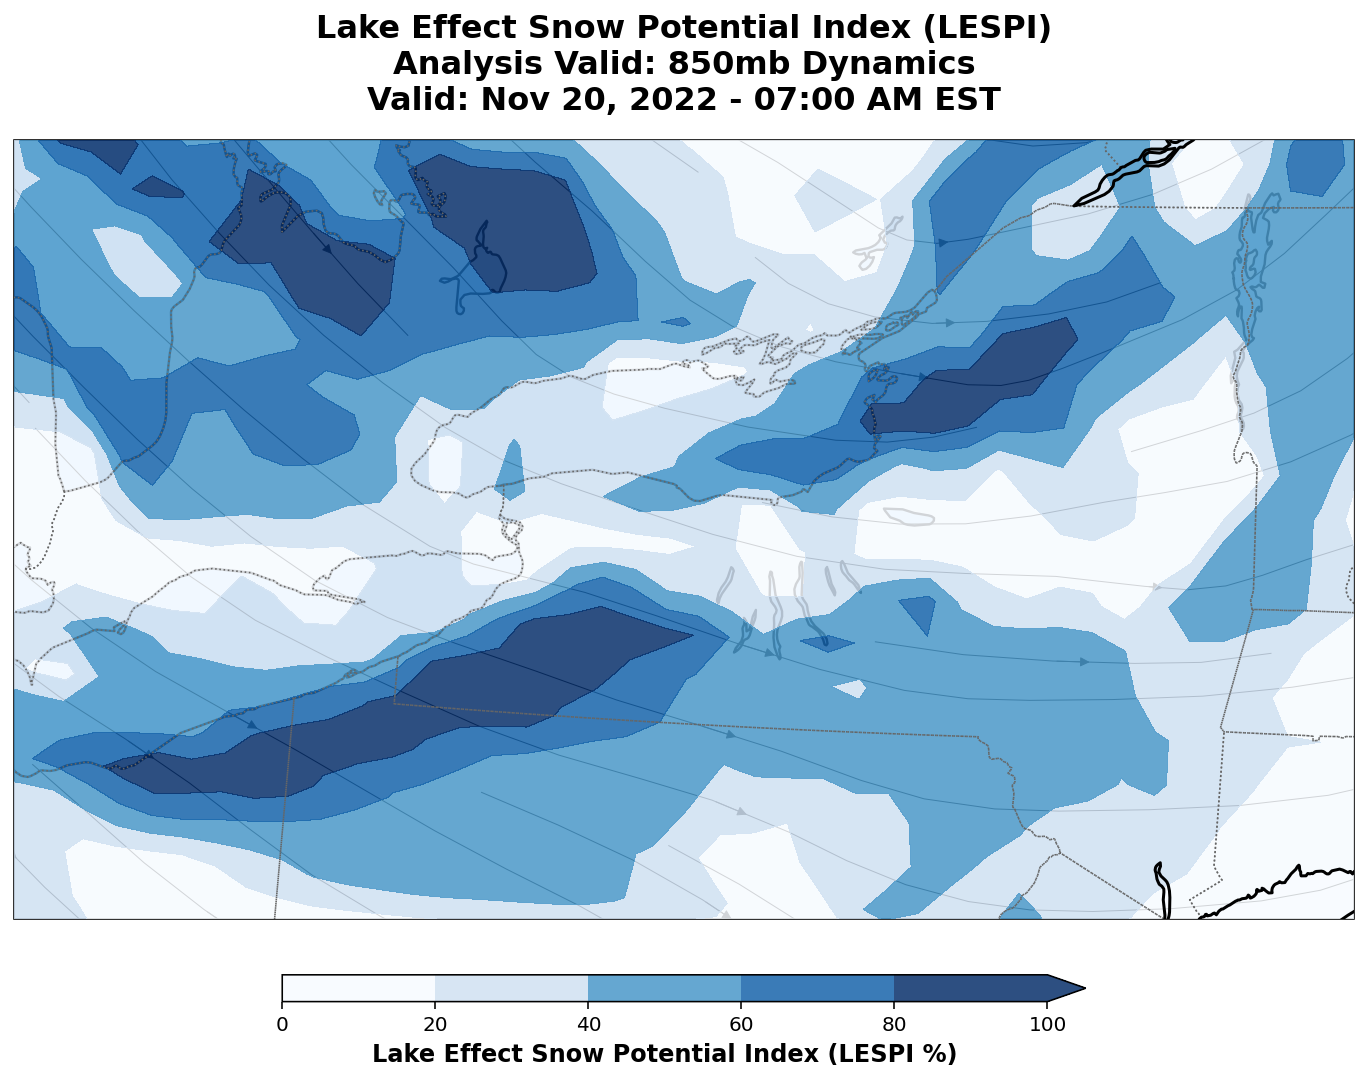

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import pandas as pd, numpy as np

fig = plt.figure(figsize=(12, 10), dpi=144)
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-72.5, central_latitude=42.0))

#Geography
res = '10m'
ax.add_feature(cfeature.LAND.with_scale(res), facecolor='#fdfdfd')
ax.add_feature(cfeature.LAKES.with_scale(res), edgecolor='black', facecolor='#d1e9ff', linewidth=1.2, zorder=2)
ax.add_feature(cfeature.STATES.with_scale(res), edgecolor='#666666', linewidth=0.8, linestyle=':', zorder=4)
ax.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', linewidth=1.5, zorder=5)



plot = ax.contourf(
    les_t.longitude, 
    les_t.latitude, 
    les_t.values, 
    levels= [0 ,20, 40, 60, 80, 100], 
    cmap=plt.get_cmap('Blues',6), 
    
    transform=ccrs.PlateCarree(),
    extend='max',
    alpha=0.85,
    zorder=3
)


ax.streamplot(ds_run.longitude.values, ds_run.latitude.values,  ds_run['u'].sel(isobaricInhPa=850).isel(valid_time=val),  ds_run['v'].sel(isobaricInhPa=850).isel(valid_time=val), transform=ccrs.PlateCarree(), density=1, linewidth = 0.5, color="black")
cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6, aspect=30)
cbar.set_label('Lake Effect Snow Potential Index (LESPI %)', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

ax.set_extent([-82.5, -72.5, 41.0, 45.0], crs=ccrs.PlateCarree())
valid_time_utc = pd.to_datetime(les_t.valid_time.values)

valid_time_est = valid_time_utc.tz_localize('UTC').tz_convert('US/Eastern')
time_str = valid_time_est.strftime('%b %d, %Y - %I:%M %p EST')

plt.title(f"Lake Effect Snow Potential Index (LESPI)\n"
          f"Analysis Valid: 850mb Dynamics\n"
          f"Valid: {time_str}", 
          fontsize=16, fontweight='bold', loc='center', pad=15)
plt.show()
plt.show()



In [64]:
time_str

'Nov 19, 2022 - 07:00 PM EST'

In [328]:
ds_run

<xarray.Dataset> Size: 8MB
Dimensions:            (valid_time: 15, latitude: 41, longitude: 81,
                        isobaricInhPa: 5)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * latitude           (latitude) float64 328B 50.0 49.75 49.5 ... 40.25 40.0
  * longitude          (longitude) float64 648B 275.0 275.2 ... 294.8 295.0
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables: (12/14)
    orog               (valid_time, latitude, longitude) float32 199kB ...
    tS                 (valid_time, latitude, longitude) float32 199kB 262.8 ...
    sit                (valid_time, latitude, longitude) float32 199kB ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    ...                 ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t2m                (valid_time, latitude, longitude) float32 199kB ...
    r2                 (valid_time, latitude, longitude) float32 199kB ...
    aptmp              (valid_time, latitude, longitude) float32 199kB ...
    tp                 (valid_time, latitude, longitude) float32 199kB nan .....
    prmsl              (valid_time, latitude, longitude) float32 199kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-01T16:40 GRIB to CDM+CF via cfgrib-0.9.1...